In [47]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, SEC_PALETTE, style_ax, legend, country_handles

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
df = pd.read_parquet("0_intermediate/df.parquet")

countries = [g for g in var_groups.countries if g != 'UK']

# Sectors without reliable GVA mapping — omit from decomposition
_excl = {'FC_IND_IS_E', 'FC_IND_NFM_E', 'FC_OTH_NSP_E', 'FC_TRA_NSP_E'}
subs_gva = [s for s in var_groups.subs if s not in _excl]

df = df[df.nrg_bal.isin(subs_gva) & df.geo.isin(countries)].copy()

### GVA-andele

Sektor $i$'s andel af samlet GVA for land $c$ i år $t$:

$$s_{i,c,t} = \frac{\text{GVA}_{i,c,t}}{\displaystyle\sum_j \text{GVA}_{j,c,t}}$$

In [49]:
def gva_shares(df_slice):
    """GVA shares and electrification rates for a country-year slice, aligned to subs_gva."""
    g = df_slice.set_index('nrg_bal')['gva_meur'].fillna(0).reindex(subs_gva, fill_value=0)
    e = df_slice.set_index('nrg_bal')['elec_share_pct'].fillna(0).reindex(subs_gva, fill_value=0)
    total = g.sum()
    s = g / total if total > 0 else g.copy()
    return s, e

### Symmetrisk shift-share dekomponering

Elektrificeringsraten $E_{c,t} = \sum_i s_{i,c,t} \cdot e_{i,c,t}$.  
Ændringen $\Delta E$ dekomponeres med midtvejsvægte $\bar{s}_i = \tfrac{s_{i,0}+s_{i,1}}{2}$, $\bar{e}_i = \tfrac{e_{i,0}+e_{i,1}}{2}$:

$$\Delta E = \underbrace{\sum_i \Delta s_i \cdot \bar{e}_i}_{\text{sammensætningseffekt}} + \underbrace{\sum_i \bar{s}_i \cdot \Delta e_i}_{\text{intensitetseffekt}} + \underbrace{\sum_i \Delta s_i \cdot \Delta e_i}_{\text{interaktionsled}}$$

In [50]:
def decompose(s0, s1, e0, e1):
    """Symmetric shift-share: returns composition + intensity + interaction = ΔE (pp)."""
    s_bar, e_bar = (s0 + s1) / 2, (e0 + e1) / 2
    ds, de = s1 - s0, e1 - e0
    return pd.Series({
        'composition': (ds * e_bar).sum(),
        'intensity':   (s_bar * de).sum(),
        'interaction': (ds * de).sum(),
    })

## Analyse 1: Tidslig dekomponering (første → seneste observation, pr. land)

In [51]:
rows = []
for geo in countries:
    sub = df[df.geo == geo]
    years = sorted(sub.year.unique())
    y0, y1 = years[0], years[-1]
    s0, e0 = gva_shares(sub[sub.year == y0])
    s1, e1 = gva_shares(sub[sub.year == y1])
    res = decompose(s0, s1, e0, e1)
    res['geo'] = geo
    res['y0']  = y0
    res['y1']  = y1
    res['E0']  = (s0 * e0).sum()
    res['E1']  = (s1 * e1).sum()
    rows.append(res)

df_time = pd.DataFrame(rows).set_index('geo')
df_time['total'] = df_time[['composition', 'intensity', 'interaction']].sum(axis=1)
df_time[['y0', 'y1', 'E0', 'E1', 'composition', 'intensity', 'interaction', 'total']].round(2)

,y0,y1,E0,E1,composition,intensity,interaction,total
geo,,,,,,,,
DK,1995,2023,38.67,41.79,0.73,2.40,-0.19,2.93
SE,1995,2023,49.10,59.06,1.82,8.14,-0.35,9.61
NO,1995,2023,73.65,58.51,-1.41,-13.73,-3.44,-18.58
DE,1995,2023,31.47,40.07,0.69,7.91,0.19,8.78
NL,1995,2023,28.38,48.00,1.42,18.20,1.23,20.85
ES,1995,2023,51.82,55.05,2.73,0.51,1.14,4.38
FR,1995,2023,41.92,52.75,0.77,10.06,0.50,11.33
FI,1995,2023,72.32,44.10,4.51,-32.73,-5.52,-33.74
EU27_2020,1995,2023,35.62,47.63,1.05,10.97,0.19,12.21


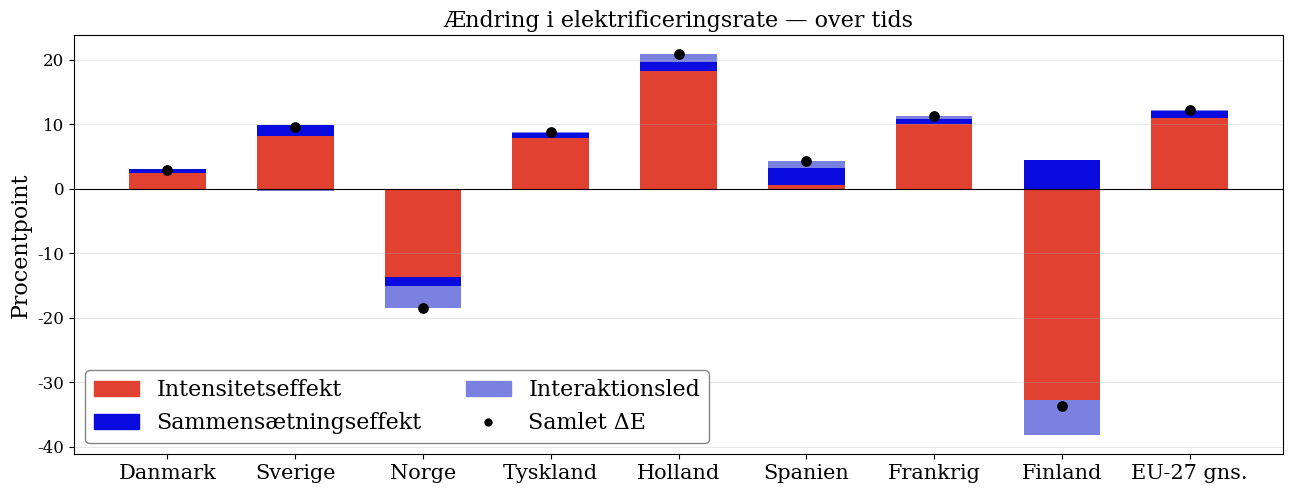

In [52]:
_COMP_COLORS = {
    'intensity':   PALETTE['DK'],        # red
    'composition': PALETTE['FR'],        # blue
    'interaction': PALETTE['FI'],        # yellow-gold (neutral contrast)
}
_COMP_LABELS = {
    'intensity':   'Intensitetseffekt',
    'composition': 'Sammensætningseffekt',
    'interaction': 'Interaktionsled',
}

def stacked_decomp_bars(ax, x, df_res, components=('intensity', 'composition', 'interaction')):
    """Stacked bars handling mixed-sign values; returns legend patches."""
    bottom_pos = np.zeros(len(x))
    bottom_neg = np.zeros(len(x))
    patches = []
    for comp in components:
        v = df_res[comp].to_numpy()
        p = np.where(v > 0, v, 0)
        n = np.where(v < 0, v, 0)
        ax.bar(x, p, bottom=bottom_pos, color=_COMP_COLORS[comp], width=0.6)
        ax.bar(x, n, bottom=bottom_neg, color=_COMP_COLORS[comp], width=0.6)
        bottom_pos += p
        bottom_neg += n
        patches.append(Patch(color=_COMP_COLORS[comp], label=_COMP_LABELS[comp]))
    return patches


# ── Fig 1: Tidslig dekomponering ──────────────────────────────────────────────
geos = df_time.index.tolist()
x = np.arange(len(geos))

fig, ax = plt.subplots(figsize=(13, 5))

patches = stacked_decomp_bars(ax, x, df_time)
ax.scatter(x, df_time['total'].to_numpy(), color='black', zorder=5, s=45,
           label='Samlet ΔE (verificering)')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{var_groups.country_names[g]}" for g in geos],
    ha='center',
)
ax.set_ylabel('Procentpoint')
ax.set_title('Ændring i elektrificeringsrate — over tids')
ax.grid(axis='y', linewidth=0.6, alpha=0.35)
ax.legend(handles=patches + [plt.Line2D([0],[0], marker='o', color='w',
          markerfacecolor='black', markersize=7, label='Samlet ΔE')],
          frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True,
          loc='lower left', ncols=2
          )
plt.tight_layout()
plt.show()

## Analyse 2: Tværsnit — DK mod øvrige lande (seneste fælles år)

In [53]:
dk_years = set(df[df.geo == 'DK'].year.unique())
year_cc  = max(dk_years)   # latest year DK has data

rows_cc = []
s_dk, e_dk = gva_shares(df[(df.geo == 'DK') & (df.year == year_cc)])

for geo in [g for g in countries if g != 'DK']:
    geo_years = sorted(df[df.geo == geo].year.unique())
    y_use = year_cc if year_cc in geo_years else max(y for y in geo_years if y <= year_cc)
    s_geo, e_geo = gva_shares(df[(df.geo == geo) & (df.year == y_use)])
    # direction: s0/e0 = comparison country, s1/e1 = DK → positive means DK is higher
    res = decompose(s_geo, s_dk, e_geo, e_dk)
    res['geo']       = geo
    res['year_dk']   = year_cc
    res['year_comp'] = y_use
    res['E_dk']      = (s_dk  * e_dk ).sum()
    res['E_comp']    = (s_geo * e_geo).sum()
    rows_cc.append(res)

df_cc = pd.DataFrame(rows_cc).set_index('geo')
df_cc['total'] = df_cc[['composition', 'intensity', 'interaction']].sum(axis=1)
df_cc[['year_comp', 'E_dk', 'E_comp', 'composition', 'intensity', 'interaction', 'total']].round(2)

,year_comp,E_dk,E_comp,composition,intensity,interaction,total
geo,,,,,,,
SE,2023,41.79,59.06,0.17,-17.45,0.93,-16.35
NO,2023,41.79,58.51,8.16,-24.88,4.67,-12.05
DE,2023,41.79,40.07,-0.91,2.63,0.94,2.66
NL,2023,41.79,48.00,-1.07,-5.15,2.75,-3.47
ES,2023,41.79,55.05,-0.02,-13.25,2.40,-10.87
FR,2023,41.79,52.75,-0.82,-10.15,2.39,-8.58
FI,2023,41.79,44.10,0.90,-3.21,0.09,-2.22
EU27_2020,2023,41.79,47.63,-0.20,-5.65,1.82,-4.03


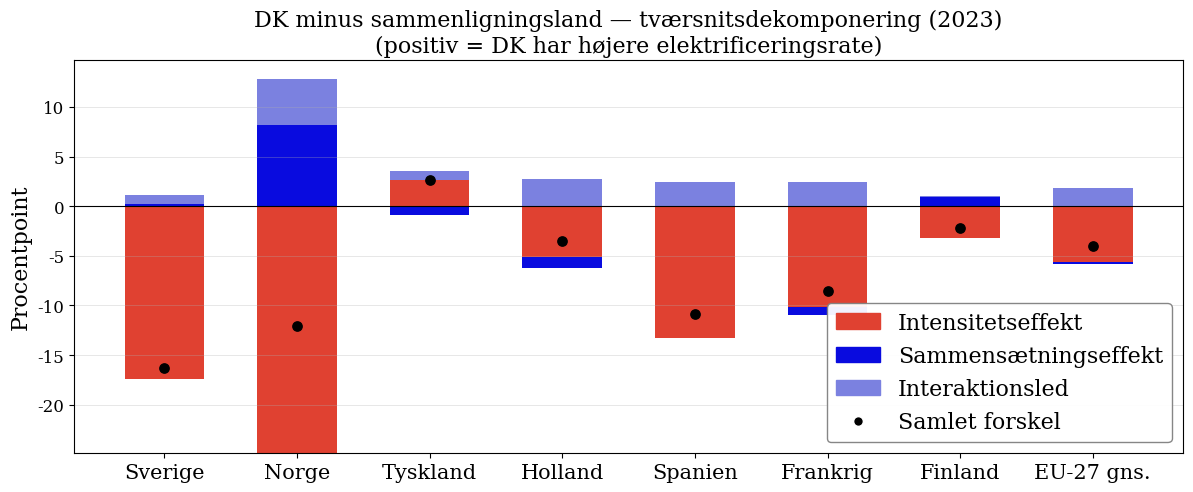

In [ ]:
# ── Fig 2: Tværsnit DK vs. øvrige lande ──────────────────────────────────────
geos_cc = df_cc.index.tolist()
x_cc = np.arange(len(geos_cc))

fig, ax = plt.subplots(figsize=(12, 5))

patches_cc = stacked_decomp_bars(ax, x_cc, df_cc)
ax.scatter(x_cc, df_cc['total'].to_numpy(), color='black', zorder=5, s=45)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_cc)
ax.set_xticklabels([var_groups.country_names[g] for g in geos_cc], ha='center')
ax.set_ylabel('Procentpoint')
ax.set_title(f'DK minus sammenligningsland — tværsnitsdekomponering ({year_cc})')
ax.grid(axis='y', linewidth=0.6, alpha=0.35)
ax.legend(handles=patches_cc + [plt.Line2D([0],[0], marker='o', color='w',
          markerfacecolor='black', markersize=7, label='Samlet forskel')],
          frameon=True, framealpha=0.95, edgecolor='0.5', fancybox=True)
plt.tight_layout()
plt.show()